# 02 · Bring your own model

Any deterministic model works with GPU if it implements the `BaseForwardModel` contract:

- `n_parameters(n_features) -> int`
- `forward(X, params) -> [n_samples, n_particles]` (vectorised over particles)

The optimiser owns the parameters; the model just evaluates them.

In [23]:
import numpy as np
from foresight_gpu import GPURegressor
from foresight_gpu.models import BaseForwardModel
from foresight_gpu.utils import plot_timeseries, plot_qq
import matplotlib.pyplot as plt
%matplotlib widget

### A linear forward model in a dozen lines

In [2]:
class LinearModel(BaseForwardModel):
    # Search weights in a normalised space, like the built-in MLP.
    scales_inputs = True
    scales_outputs = True

    def n_parameters(self, n_features):
        return n_features + 1              # weights + bias

    def forward(self, X, params):
        params = np.atleast_2d(params)     # [n_particles, n_features + 1]
        w, b = params[:, :-1], params[:, -1]
        return np.einsum('nf,pf->np', X, w) + b[None, :]  # [n_samples, n_particles]

### Drop it into `GPURegressor`

R2 = 0.108
bands shape (400, 3)


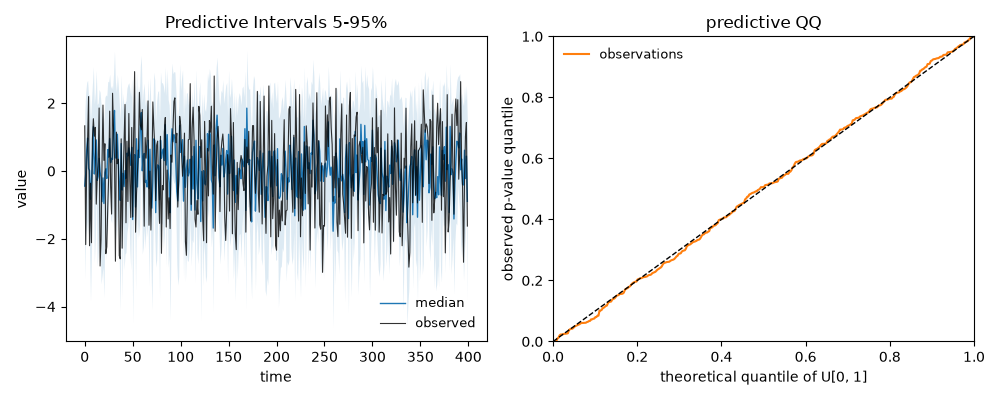

In [27]:
rng = np.random.default_rng(0)
X = rng.uniform(-1, 1, size=(400, 3))
y = 2 * X[:, 0] - X[:, 1] + 0.3 * rng.standard_normal(400)

gpu = GPURegressor(model=LinearModel(), metric='nse', population=300,
                   n_iter=80, random_state=0).fit(X, y)

predictions = gpu.predict_quantiles(X, quantiles=[0.05, 0.5, 0.95])
print('R2 =', round(gpu.score(X, y), 3))
print('bands shape', predictions.shape)

#plot_timeseries(bands, quantiles, observed=None, index=None, ax=None, color="C0"):
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax0, ax1 = axes
plot_timeseries(predictions, quantiles=[0.05, 0.5, 0.95], observed=y, ax=ax0, color="C0")
ax0.set_title('Predictive Intervals 5-95%')
plot_qq(gpu.predictive_pvalues(X, y), ax=ax1)
ax1.set_title('predictive QQ')
fig.tight_layout()

That is all it takes. The built-in `MLPModel` and hydrological `GR4JModel` follow the same contract — see `foresight_gpu/models/`.